# 06 - Prophet Forecasting Model

## Analytical Objectives

- Prepare Walmart weekly sales data for Prophet.
- Aggregate sales into a single weekly time series.
- Create chronological training and testing datasets.
- Train a Prophet forecasting model.
- Capture yearly and weekly seasonal patterns.
- Generate forecasts for the test period.
- Evaluate forecast accuracy using MAE, RMSE, and MAPE.
- Compare Prophet performance against the Naïve Baseline.
- Analyze Prophet's estimated trend and seasonal components.

## Expected Outcome

By the end of this notebook, we will have:

- A trained Prophet forecasting model.
- Forecasted Walmart weekly sales.
- Model evaluation metrics.
- Actual vs predicted visualizations.
- Trend and seasonality analysis.
- A direct comparison between Prophet and the Naïve Baseline.

#### Install Prophet

#### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

#### Load Dataset

In [3]:
train = pd.read_csv(
    "../data/processed/train_clean.csv"
)

train["Date"] = pd.to_datetime(train["Date"])

train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106


In [4]:
train.shape

(421570, 16)

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Type          421570 non-null  str           
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     421570 non-null  float64       
 10  MarkDown2     421570 non-null  float64       
 11  MarkDown3     421570 non-null  float64       
 12  MarkDown4     421570 non-null  float64       
 13  MarkDown5     421570 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421570 non-nul

#### Prepare Prophet Dataset

In [6]:
#Walmart sales by date

prophet_data = (
    train.groupby("Date")["Weekly_Sales"]
         .sum()
         .reset_index()
)

In [7]:
#Rename the columns

prophet_data = prophet_data.rename(
    columns={
        "Date": "ds",
        "Weekly_Sales": "y"
    }
)

In [8]:
prophet_data.head()

,ds,y
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [9]:
#Verify Weekly Frequency

prophet_data["ds"].diff().value_counts().head()

ds
7 days    142
Name: count, dtype: int64

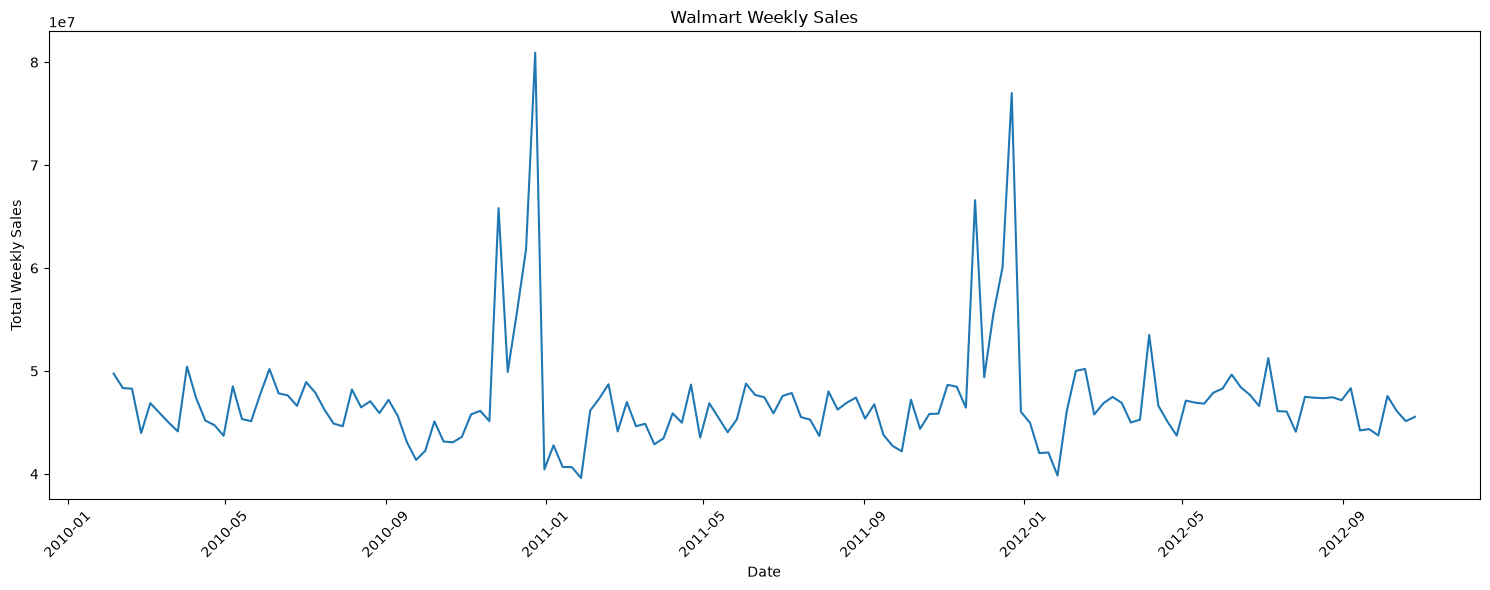

In [10]:
#Plot the Historical Series

plt.figure(figsize=(15, 6))

plt.plot(
    prophet_data["ds"],
    prophet_data["y"]
)

plt.title("Walmart Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Train-Test Split

In [11]:
split_date = pd.Timestamp("2012-06-01")

In [12]:
#Training data:

prophet_train = prophet_data[
    prophet_data["ds"] < split_date
].copy()

In [13]:
#Testing data:

prophet_test = prophet_data[
    prophet_data["ds"] >= split_date
].copy()

In [14]:
#Verify:

print(
    "Training Shape:",
    prophet_train.shape
)

print(
    "Testing Shape:",
    prophet_test.shape
)

Training Shape: (121, 2)
Testing Shape: (22, 2)


In [15]:
#Check date ranges:

print(
    "Training:",
    prophet_train["ds"].min(),
    "to",
    prophet_train["ds"].max()
)

print(
    "Testing:",
    prophet_test["ds"].min(),
    "to",
    prophet_test["ds"].max()
)

Training: 2010-02-05 00:00:00 to 2012-05-25 00:00:00
Testing: 2012-06-01 00:00:00 to 2012-10-26 00:00:00


#### Build Prophet Model

In [16]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

#### Add Custom Monthly Seasonality

In [17]:
model.add_seasonality(
    name="monthly",
    period=30.5,
    fourier_order=5
)

#### Train Prophet

In [18]:
model.fit(prophet_train)

21:37:01 - cmdstanpy - INFO - Chain [1] start processing
21:37:01 - cmdstanpy - INFO - Chain [1] done processing


#### Generate Future Dates

In [19]:
future = model.make_future_dataframe(
    periods=len(prophet_test),
    freq="W-FRI"
)

In [20]:
future.tail()

,ds
138,2012-09-28
139,2012-10-05
140,2012-10-12
141,2012-10-19
142,2012-10-26


#### Generate Forecast

In [21]:
forecast = model.predict(future)

In [22]:
forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].tail()

,ds,yhat,yhat_lower,yhat_upper
138,2012-09-28,4.340993e+07,3.901495e+07,4.788251e+07
139,2012-10-05,4.746125e+07,4.299269e+07,5.215409e+07
140,2012-10-12,4.566984e+07,4.123850e+07,4.975321e+07
141,2012-10-19,4.385321e+07,3.916814e+07,4.804306e+07
142,2012-10-26,4.631608e+07,4.209589e+07,5.068490e+07


#### Extract Test Predictions

In [23]:
prophet_predictions = forecast[
    forecast["ds"] >= split_date
][
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].copy()

#### Combine Actual and Predicted Sales

In [24]:
prophet_results = prophet_test.merge(
    prophet_predictions,
    on="ds",
    how="left"
)

In [25]:
prophet_results.head()

,ds,y,yhat,yhat_lower,yhat_upper
0,2012-06-01,48281649.72,4.384301e+07,3.913363e+07,4.844771e+07
1,2012-06-08,49651171.78,4.781464e+07,4.331846e+07,5.217727e+07
2,2012-06-15,48412110.70,4.808020e+07,4.349464e+07,5.234513e+07
3,2012-06-22,47668284.97,5.017848e+07,4.592759e+07,5.461439e+07
4,2012-06-29,46597112.12,4.737059e+07,4.284049e+07,5.188493e+07


In [26]:
#Verify Predictions

prophet_results[
    [
        "ds",
        "y",
        "yhat"
    ]
].head(10)

,ds,y,yhat
0,2012-06-01,48281649.72,4.384301e+07
1,2012-06-08,49651171.78,4.781464e+07
2,2012-06-15,48412110.70,4.808020e+07
3,2012-06-22,47668284.97,5.017848e+07
4,2012-06-29,46597112.12,4.737059e+07
5,2012-07-06,51253021.88,4.937199e+07
6,2012-07-13,46099732.10,4.617336e+07
7,2012-07-20,46059543.45,4.546947e+07
8,2012-07-27,44097154.97,4.834191e+07
9,2012-08-03,47485899.56,4.619897e+07


In [27]:
#Check Missing Predictions

prophet_results[
    ["y", "yhat"]
].isnull().sum()

y       0
yhat    0
dtype: int64

#### Calculate MAE,RMSE,MAPE

In [28]:
prophet_mae = mean_absolute_error(
    prophet_results["y"],
    prophet_results["yhat"]
)

print(
    f"Prophet MAE: {prophet_mae:,.2f}"
)

Prophet MAE: 1,385,515.01


In [29]:
prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_results["y"],
        prophet_results["yhat"]
    )
)

print(
    f"Prophet RMSE: {prophet_rmse:,.2f}"
)

Prophet RMSE: 1,838,681.01


In [30]:
prophet_mape = (
    mean_absolute_percentage_error(
        prophet_results["y"],
        prophet_results["yhat"]
    ) * 100
)

print(
    f"Prophet MAPE: {prophet_mape:.2f}%"
)

Prophet MAPE: 2.95%


#### Prophet Performance Summary


In [31]:
prophet_summary = pd.DataFrame({
    "Model": ["Prophet"],
    "MAE": [prophet_mae],
    "RMSE": [prophet_rmse],
    "MAPE": [prophet_mape]
})

prophet_summary

,Model,MAE,RMSE,MAPE
0,Prophet,1.385515e+06,1.838681e+06,2.945324


#### Actual vs Predicted Sales

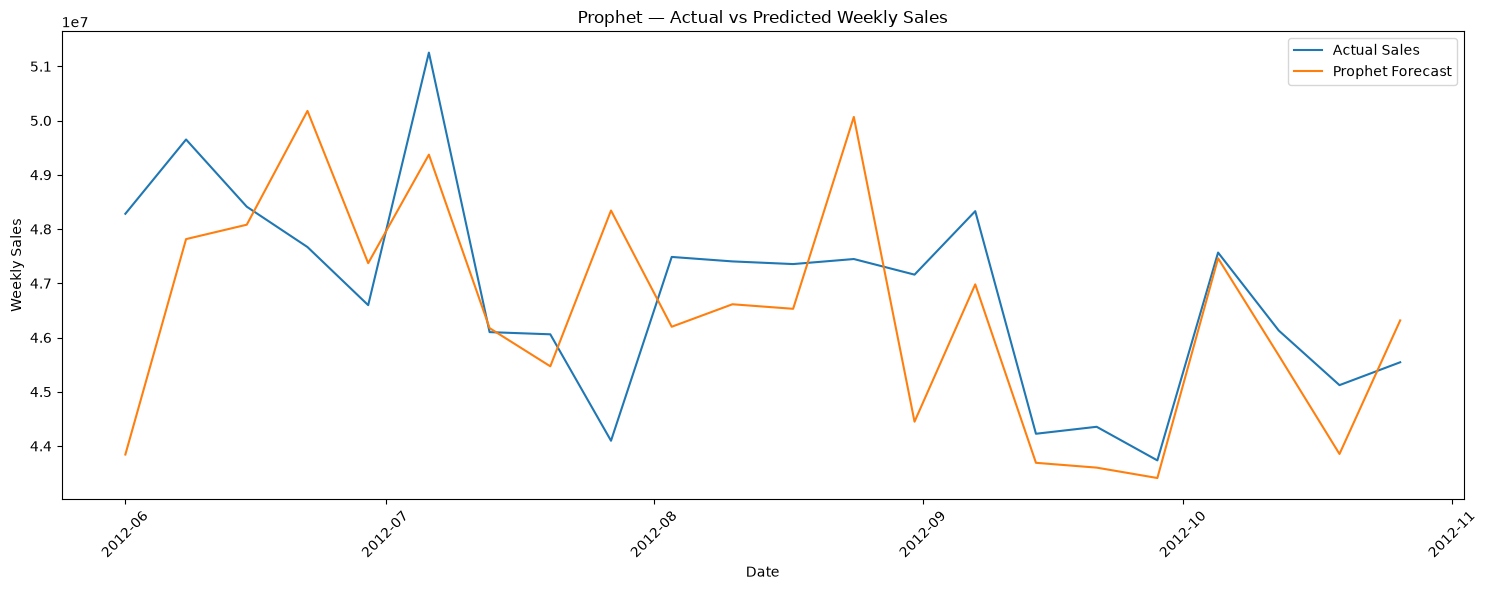

In [32]:
plt.figure(figsize=(15, 6))

plt.plot(
    prophet_results["ds"],
    prophet_results["y"],
    label="Actual Sales"
)

plt.plot(
    prophet_results["ds"],
    prophet_results["yhat"],
    label="Prophet Forecast"
)

plt.title(
    "Prophet — Actual vs Predicted Weekly Sales"
)

plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Forecast with Confidence Interval

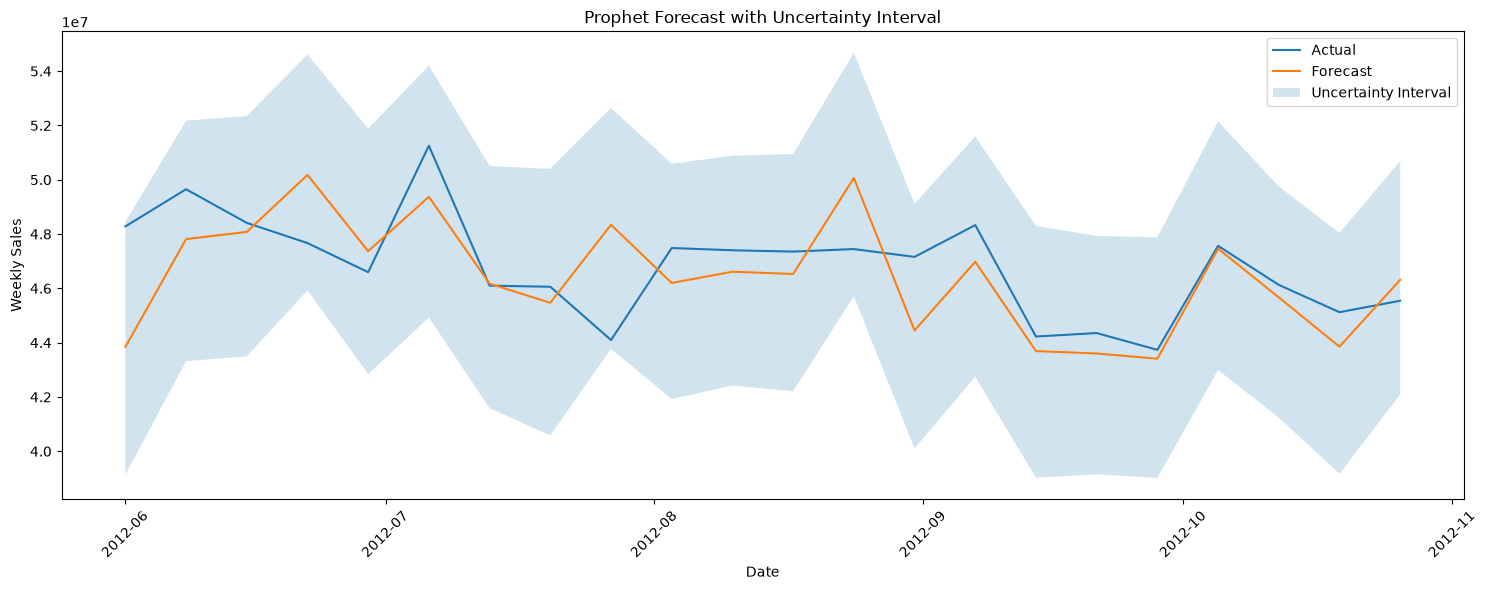

In [33]:
plt.figure(figsize=(15, 6))

plt.plot(
    prophet_results["ds"],
    prophet_results["y"],
    label="Actual"
)

plt.plot(
    prophet_results["ds"],
    prophet_results["yhat"],
    label="Forecast"
)

plt.fill_between(
    prophet_results["ds"],
    prophet_results["yhat_lower"],
    prophet_results["yhat_upper"],
    alpha=0.2,
    label="Uncertainty Interval"
)

plt.title(
    "Prophet Forecast with Uncertainty Interval"
)

plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Prophet Components

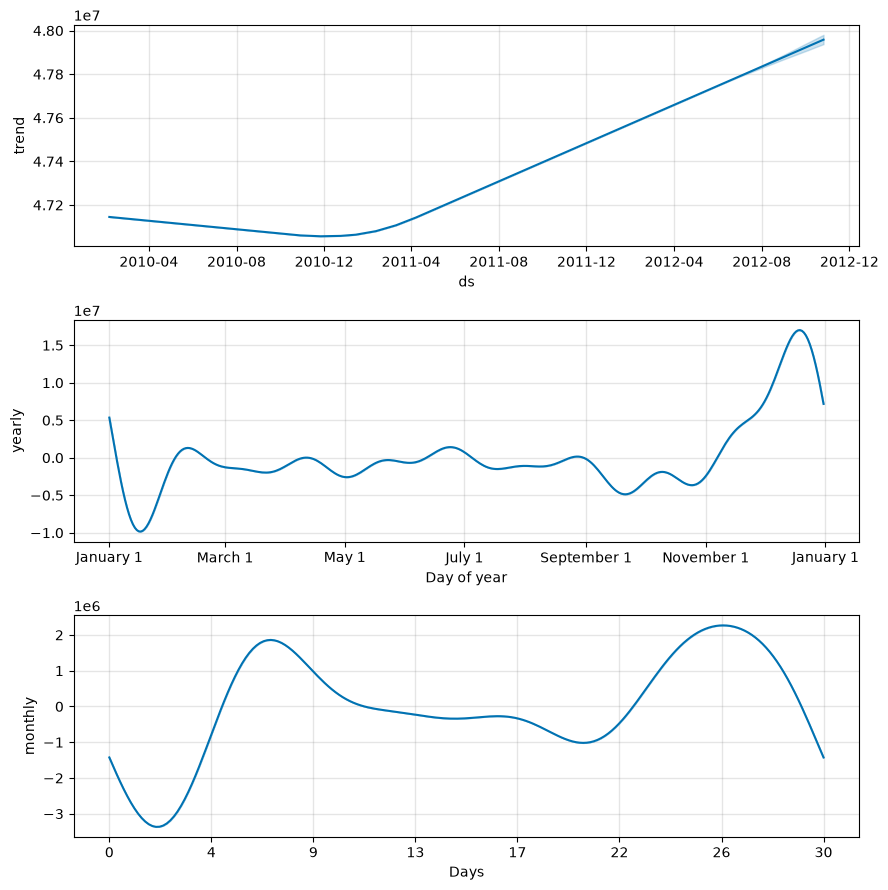

In [34]:
fig = model.plot_components(
    forecast
)

plt.show()

#### Residual Analysis

In [35]:
#Create residuals:

prophet_results["Residual"] = (
    prophet_results["y"]
    - prophet_results["yhat"]
)

In [36]:
#Check:

prophet_results[
    [
        "ds",
        "y",
        "yhat",
        "Residual"
    ]
].head()

,ds,y,yhat,Residual
0,2012-06-01,48281649.72,4.384301e+07,4.438639e+06
1,2012-06-08,49651171.78,4.781464e+07,1.836529e+06
2,2012-06-15,48412110.70,4.808020e+07,3.319065e+05
3,2012-06-22,47668284.97,5.017848e+07,-2.510191e+06
4,2012-06-29,46597112.12,4.737059e+07,-7.734798e+05


In [37]:
#Residual Statistics

prophet_results["Residual"].describe()

count    2.200000e+01
mean     3.860671e+05
std      1.839997e+06
min     -4.244758e+06
25%     -2.887381e+04
50%      5.628394e+05
75%      1.282496e+06
max      4.438639e+06
Name: Residual, dtype: float64

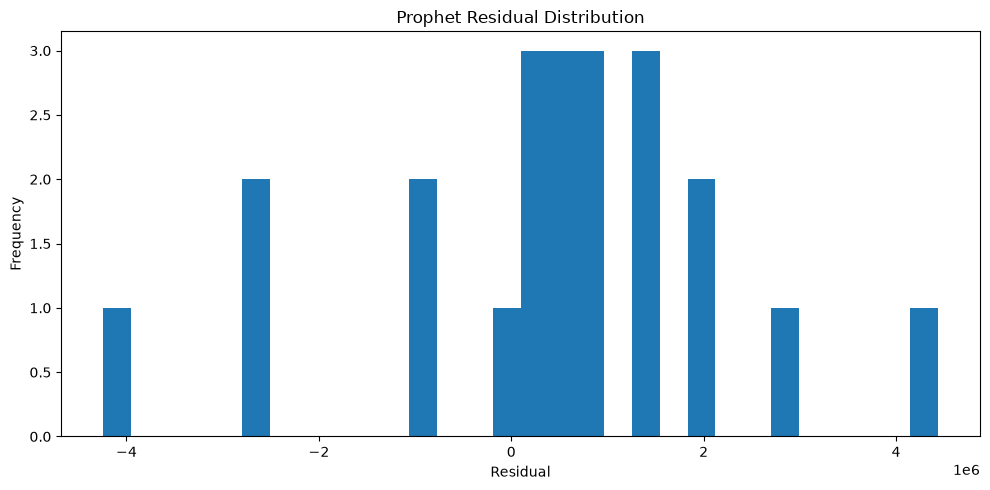

In [38]:
#Residual Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    prophet_results["Residual"],
    bins=30
)

plt.title(
    "Prophet Residual Distribution"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Compare Prophet Against Baseline

In [41]:
#Baseline 
baseline_results = pd.read_csv(
    "../reports/figures/baseline_results.csv"
)

baseline_results

,Model,MAE,RMSE,MAPE
0,Naive Baseline,1540.862076,3476.166405,5.397247e+15


In [42]:
#Create a combined comparison:

prophet_model_comparison = pd.concat(
    [
        baseline_results,
        prophet_summary
    ],
    ignore_index=True
)

prophet_model_comparison

,Model,MAE,RMSE,MAPE
0,Naive Baseline,1.540862e+03,3.476166e+03,5.397247e+15
1,Prophet,1.385515e+06,1.838681e+06,2.945324e+00


In [43]:
#Sort by MAE

prophet_model_comparison.sort_values(
    "MAE"
)

,Model,MAE,RMSE,MAPE
0,Naive Baseline,1.540862e+03,3.476166e+03,5.397247e+15
1,Prophet,1.385515e+06,1.838681e+06,2.945324e+00


In [48]:
#Save Prophet Results

prophet_results.to_csv(
    "../data/processed/prophet_predictions.csv",
    index=False
)

In [49]:
#Save the comparison:

prophet_model_comparison.to_csv(
    "../reports/figures/prophet_model_comparison.csv",
    index=False
)

In [51]:
prophet_summary.to_csv(
    "../reports/figures/prophet_summary.csv"
)

### Key Observations

- Prophet successfully modeled the aggregated Walmart weekly sales series.
- The model captured the overall historical trend and recurring seasonal patterns.
- Prophet generated both point forecasts and uncertainty intervals.
- Forecast accuracy was evaluated using MAE, RMSE, and MAPE.
- MAE and RMSE provide the primary basis for comparing Prophet with the Naïve Baseline.
- Prophet's component analysis provides insight into long-term trends and seasonal behavior.
- The model's performance should be evaluated against the Naïve Baseline before considering it an improvement.

### Executive Summary

The Prophet model was developed to provide a more sophisticated time-series forecasting benchmark than the Naïve Baseline.

Unlike the Naïve Baseline, Prophet explicitly models temporal trends and seasonal patterns. The model was trained using historical aggregate Walmart weekly sales and evaluated on a future holdout period using MAE, RMSE, and MAPE.

The resulting forecasts provide both predicted sales and uncertainty intervals, while Prophet's component analysis provides additional insight into the underlying trend and seasonal structure of Walmart sales.

Prophet performance will be compared directly with the Naïve Baseline. This comparison establishes whether explicit trend and seasonality modeling provides a meaningful improvement in forecasting accuracy.

The next stage will move from traditional time-series forecasting toward machine learning-based forecasting using XGBoost, where the engineered lag, rolling, holiday, store, department, and external economic features can be incorporated simultaneously.